# Human Activity Recognition: RNN vs LSTM vs GRU
**Dataset:** UCI HAR (Kaggle) – smartphone sensor data of 30 people doing 6 activities
(Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying).

**Goal:** Train 3 recurrent models and compare their accuracy.

## Cell 1 – Import libraries
- `pandas`, `numpy` → load and handle data
- `sklearn` → encode labels, scale features, evaluate
- `tensorflow.keras` → build RNN, LSTM, GRU models

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Cell 2 – Load the data
- On **Kaggle**: add the dataset to the notebook, the path is picked automatically.
- On **Colab / PC**: download `train.csv` and `test.csv` and keep them in the same folder as this notebook.

In [18]:
kaggle_path = '/kaggle/input/human-activity-recognition-with-smartphones/'

if os.path.exists(kaggle_path + 'train.csv'):
    path = kaggle_path
else:
    path = ''   # files are in the same folder as the notebook

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (7352, 563)
Test shape : (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


## Cell 3 – Explore the data
- 561 feature columns + `subject` (person ID) + `Activity` (label).
- Check missing values and how many samples each activity has.

Missing values in train: 0
Missing values in test : 0


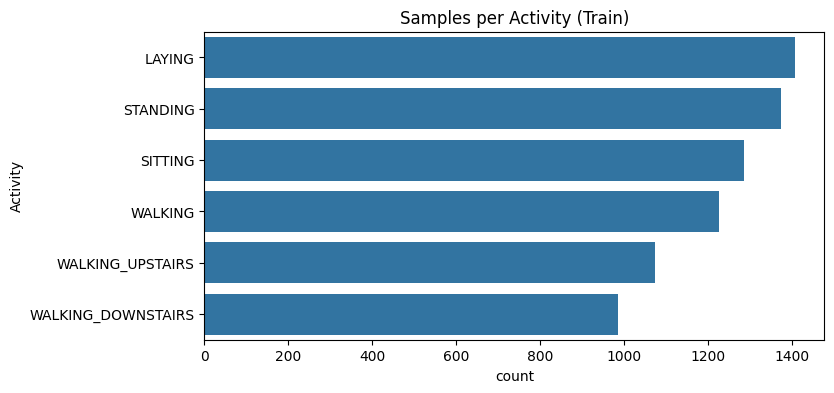

In [19]:
print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test :", test.isnull().sum().sum())

plt.figure(figsize=(8, 4))
sns.countplot(y=train['Activity'], order=train['Activity'].value_counts().index)
plt.title('Samples per Activity (Train)')
plt.show()

## Cell 4 – Separate features (X) and labels (y)
- Drop `subject` (not useful for prediction) and `Activity` (it is the target).

In [20]:
train_cleaned = train.dropna(subset=['Activity'])

X_train = train_cleaned.drop(['subject', 'Activity'], axis=1).values
y_train = train_cleaned['Activity'].values

X_test = test.drop(['subject', 'Activity'], axis=1).values
y_test = test['Activity'].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (7352, 561)  X_test: (2947, 561)


## Cell 5 – Encode labels
- Neural networks need numbers, not text.
- `LabelEncoder` converts activity names → 0 to 5.

In [21]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

class_names = encoder.classes_
num_classes = len(class_names)
for i, name in enumerate(class_names):
    print(i, '->', name)

0 -> LAYING
1 -> SITTING
2 -> STANDING
3 -> WALKING
4 -> WALKING_DOWNSTAIRS
5 -> WALKING_UPSTAIRS


## Cell 6 – Scale features
- `StandardScaler` makes every feature have mean 0 and std 1.
- Helps the model train faster and more stably.
- Fit only on train data, then apply same scaling to test.

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Cell 7 – Reshape into sequences
- RNN/LSTM/GRU need 3D input: **(samples, timesteps, features)**.
- This Kaggle version has 561 features per row (not raw time signals), so we reshape
  561 = **33 timesteps × 17 features** to feed it as a sequence.

In [23]:
TIMESTEPS = 33
FEATURES = 17

X_train = X_train.reshape(-1, TIMESTEPS, FEATURES)
X_test = X_test.reshape(-1, TIMESTEPS, FEATURES)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (7352, 33, 17)
X_test : (2947, 33, 17)


## Cell 8 – Function to build a model
One function builds all 3 models; we only change the layer type.
- 2 recurrent layers (64 → 32 units); `return_sequences=True` passes the full sequence to the next layer.
- `Dropout` reduces overfitting.
- `Dense(6, softmax)` gives probability for each activity.

In [24]:
def build_model(layer_type):
    model = Sequential([
        Input(shape=(TIMESTEPS, FEATURES)),
        layer_type(64, return_sequences=True),
        Dropout(0.2),
        layer_type(32),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

## Cell 9 – Function to train and evaluate
- Trains for up to 30 epochs; 20% of train data is used for validation.
- `EarlyStopping` stops training when validation loss stops improving and keeps the best weights.
- Returns training history and test accuracy.

In [25]:
EPOCHS = 30
BATCH_SIZE = 64

def train_and_evaluate(model, name):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=0.2,
                        callbacks=[early_stop],
                        verbose=1)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{name} Test Accuracy: {acc*100:.2f}%")
    return history, acc

## Cell 10 – Model 1: Simple RNN
- Basic recurrent layer: remembers previous timesteps using a hidden state.
- Weakness: forgets long-range information (vanishing gradient).

In [26]:
rnn_model = build_model(SimpleRNN)
rnn_model.summary()
rnn_history, rnn_acc = train_and_evaluate(rnn_model, 'Simple RNN')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 33, 64)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,550 (33.40 KB)

 Trainable params: 8,550 (33.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6307 - loss: 0.9126 - val_accuracy: 0.8199 - val_loss: 0.5393
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8427 - loss: 0.4523 - val_accuracy: 0.8885 - val_loss: 0.3555
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8876 - loss: 0.3195 - val_accuracy: 0.9116 - val_loss: 0.3080
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9145 - loss: 0.2443 - val_accuracy: 0.9177 - val_loss: 0.2841
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9306 - loss: 0.2020 - val_accuracy: 0.9191 - val_loss: 0.2696
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9444 - loss: 0.1715 - val_accuracy: 0.9218 - val_loss: 0.2658
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9469 - loss: 0.1508 - val_accuracy: 0.9259 - val_loss: 0.2631
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9563 - loss: 0.1293 - val_accuracy: 0.9205 - v

## Cell 11 – Model 2: LSTM
- Long Short-Term Memory: has **input, forget and output gates** + a cell state.
- Gates decide what to keep or forget → remembers long sequences better than RNN.

In [27]:
lstm_model = build_model(LSTM)
lstm_model.summary()
lstm_history, lstm_acc = train_and_evaluate(lstm_model, 'LSTM')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 33, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,606 (131.27 KB)

 Trainable params: 33,606 (131.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.4392 - loss: 1.2269 - val_accuracy: 0.6642 - val_loss: 0.9097
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7099 - loss: 0.7020 - val_accuracy: 0.7791 - val_loss: 0.5588
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7888 - loss: 0.4735 - val_accuracy: 0.8334 - val_loss: 0.4886
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8206 - loss: 0.3929 - val_accuracy: 0.8763 - val_loss: 0.4548
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8420 - loss: 0.3541 - val_accuracy: 0.8906 - val_loss: 0.4347
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8643 - loss: 0.3099 - val_accuracy: 0.8668 - val_loss: 0.4086
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8769 - loss: 0.2899 - val_accuracy: 0.8742 - val_loss: 0.3931
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8930 - loss: 0.2493 - val_accuracy: 0.9205 - v

## Cell 12 – Model 3: GRU
- Gated Recurrent Unit: simpler version of LSTM with only **update and reset gates**.
- Fewer parameters → trains faster, often similar accuracy to LSTM.

In [28]:
gru_model = build_model(GRU)
gru_model.summary()
gru_history, gru_acc = train_and_evaluate(gru_model, 'GRU')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 33, 64)         │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,542 (99.77 KB)

 Trainable params: 25,542 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5535 - loss: 1.0244 - val_accuracy: 0.8056 - val_loss: 0.7364
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.7536 - loss: 0.5971 - val_accuracy: 0.8083 - val_loss: 0.5812
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8531 - loss: 0.3908 - val_accuracy: 0.8702 - val_loss: 0.4925
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9049 - loss: 0.2667 - val_accuracy: 0.8722 - val_loss: 0.4538
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9177 - loss: 0.2163 - val_accuracy: 0.8939 - val_loss: 0.4218
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9384 - loss: 0.1702 - val_accuracy: 0.8980 - val_loss: 0.3729
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9488 - loss: 0.1414 - val_accuracy: 0.9021 - val_loss: 0.3673
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9563 - loss: 0.1210 - val_accuracy: 0.9096 - v

## Cell 13 – Compare training curves
- Plots validation accuracy and loss per epoch for all 3 models.

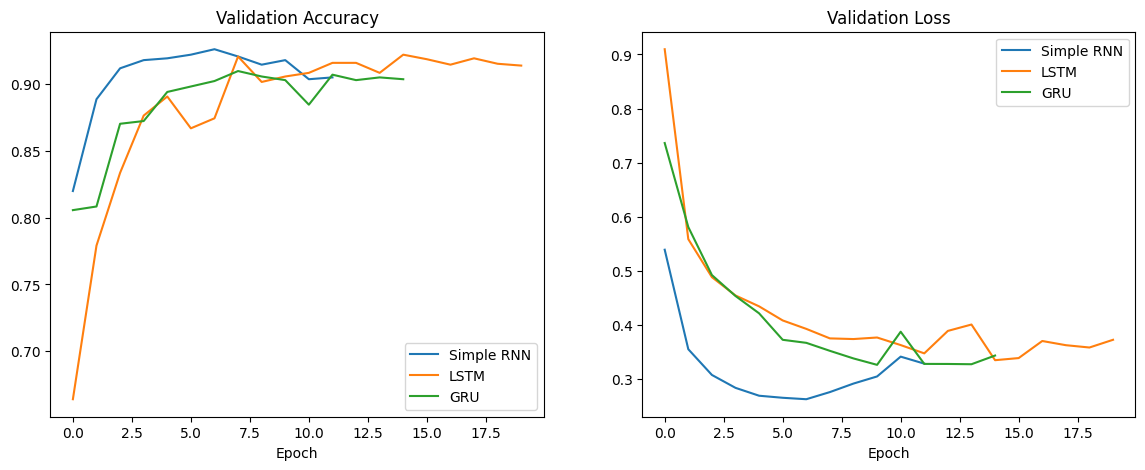

In [29]:
histories = {'Simple RNN': rnn_history, 'LSTM': lstm_history, 'GRU': gru_history}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    ax[0].plot(h.history['val_accuracy'], label=name)
    ax[1].plot(h.history['val_loss'], label=name)

ax[0].set_title('Validation Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].set_title('Validation Loss');     ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.show()

## Cell 14 – Compare test accuracy
- Bar chart + table of final test accuracy.

        Model  Test Accuracy (%)
0  Simple RNN              89.72
1        LSTM              88.23
2         GRU              90.36


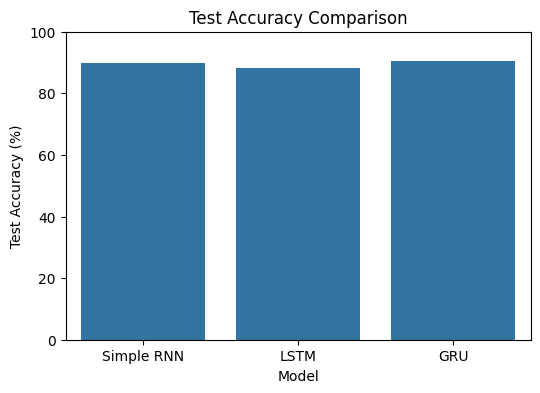

In [30]:
results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'GRU'],
    'Test Accuracy (%)': [rnn_acc*100, lstm_acc*100, gru_acc*100]
}).round(2)
print(results)

plt.figure(figsize=(6, 4))
sns.barplot(data=results, x='Model', y='Test Accuracy (%)')
plt.ylim(0, 100)
plt.title('Test Accuracy Comparison')
plt.show()

## Cell 15 – Detailed report of the best model
- Picks the model with highest accuracy.
- **Classification report:** precision, recall, F1-score per activity.
- **Confusion matrix:** shows which activities get confused (usually Sitting vs Standing).

Best model: GRU
                    precision    recall  f1-score   support

            LAYING       1.00      0.95      0.97       537
           SITTING       0.88      0.86      0.87       491
          STANDING       0.84      0.89      0.86       532
           WALKING       0.88      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.79      0.87       420
  WALKING_UPSTAIRS       0.88      0.94      0.91       471

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947



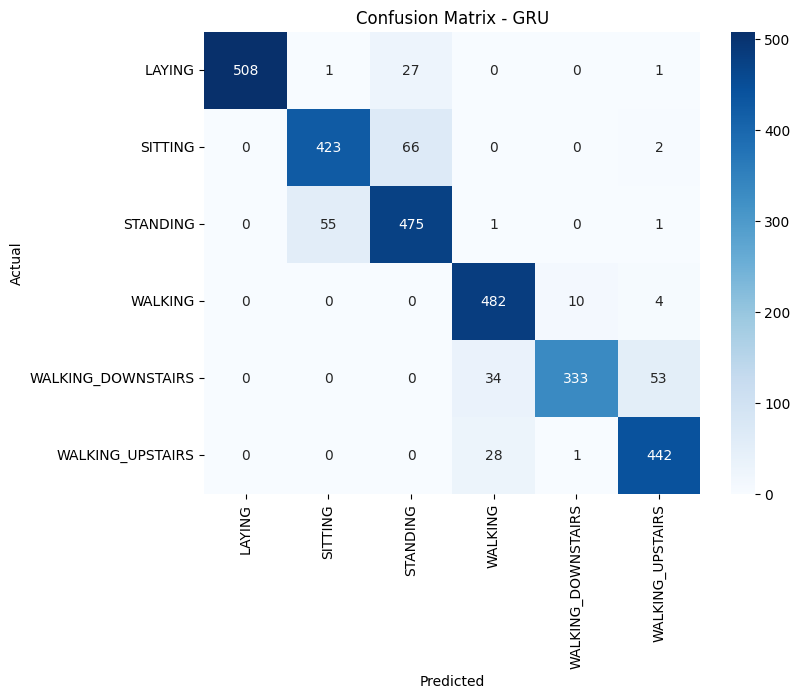

In [31]:
models = {'Simple RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}
best_name = results.loc[results['Test Accuracy (%)'].idxmax(), 'Model']
best_model = models[best_name]
print("Best model:", best_name)

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

## Cell 16 – Predict a single sample
- Takes one test sample and shows actual vs predicted activity.

In [32]:
i = 10   # change this index to test other samples
sample = X_test[i].reshape(1, TIMESTEPS, FEATURES)
pred = np.argmax(best_model.predict(sample, verbose=0))

print("Actual   :", class_names[y_test[i]])
print("Predicted:", class_names[pred])

Actual   : STANDING
Predicted: STANDING


## Conclusion
- **Simple RNN** – simplest, but struggles to remember long sequences.
- **LSTM** – gates help it keep useful information longer; usually more accurate.
- **GRU** – similar power to LSTM with fewer parameters, so faster training.
- Most errors come from **Sitting vs Standing**, as their sensor patterns are very similar.